# Drone classification

## Library Importing

In [143]:
!pip install catboost

In [144]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import make_pipeline
from catboost import CatBoostClassifier

random_state = 12345

## Data Loading

In [145]:
data = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [146]:
data.head()

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4,target
0,75516,1731.4840,411.7352,245.7620,0.8023,310.0806,0.9148,82546,0.7169,1.6753,0.3165,0.7531,0.0055,0.0033,0.5672,0.9502,1
1,98903,1374.4370,477.2451,269.7676,0.8249,354.8622,0.9585,103181,0.7679,1.7691,0.6579,0.7436,0.0048,0.0027,0.5529,0.9781,0
2,84746,1311.1570,482.7735,235.9040,0.8725,328.4843,0.9121,92914,0.7162,2.0465,0.6195,0.6804,0.0057,0.0028,0.4630,0.9474,1
3,98184,1463.1680,434.3769,292.6472,0.7390,353.5700,0.9543,102890,0.7316,1.4843,0.5763,0.8140,0.0044,0.0030,0.6625,0.9834,0
4,94170,1267.7271,440.1109,278.4162,0.7745,346.2672,0.9643,97656,0.6836,1.5808,0.7363,0.7868,0.0047,0.0030,0.6190,0.9785,0


In [147]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1288 entries, 0 to 1287
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           1288 non-null   int64  
 1   perimeter      1288 non-null   float64
 2   major_axis     1288 non-null   float64
 3   minor_axis     1288 non-null   float64
 4   eccentricity   1288 non-null   float64
 5   eqdiasq        1288 non-null   float64
 6   solidity       1288 non-null   float64
 7   convex_area    1288 non-null   int64  
 8   extent         1288 non-null   float64
 9   aspect_ratio   1288 non-null   float64
 10  roundness      1288 non-null   float64
 11  compactness    1288 non-null   float64
 12  shapefactor_1  1288 non-null   float64
 13  shapefactor_2  1288 non-null   float64
 14  shapefactor_3  1288 non-null   float64
 15  shapefactor_4  1288 non-null   float64
 16  target         1288 non-null   int64  
dtypes: float64(14), int64(3)
memory usage: 171.2 KB


In [148]:
test.head()

,area,perimeter,major_axis,minor_axis,eccentricity,eqdiasq,solidity,convex_area,extent,aspect_ratio,roundness,compactness,shapefactor_1,shapefactor_2,shapefactor_3,shapefactor_4
0,93313,1862.7260,447.1666,278.4893,0.7824,344.6880,0.9361,99678,0.7607,1.6057,0.3380,0.7708,0.0048,0.0030,0.5942,0.9541
1,78778,2159.5969,439.1004,240.0113,0.8374,316.7069,0.9340,84345,0.7265,1.8295,0.2123,0.7213,0.0056,0.0030,0.5202,0.9517
2,74757,1661.6720,441.6910,225.3914,0.8600,308.5183,0.9359,79873,0.7255,1.9597,0.3402,0.6985,0.0059,0.0030,0.4879,0.9561
3,88074,2199.8889,460.8836,283.3717,0.7886,334.8721,0.8709,101133,0.6922,1.6264,0.2287,0.7266,0.0052,0.0032,0.5279,0.8586
4,79318,2589.4900,429.3032,279.5817,0.7589,317.7905,0.8666,91528,0.6634,1.5355,0.1486,0.7402,0.0054,0.0035,0.5480,0.8414


In [149]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 430 entries, 0 to 429
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   area           430 non-null    int64  
 1   perimeter      430 non-null    float64
 2   major_axis     430 non-null    float64
 3   minor_axis     430 non-null    float64
 4   eccentricity   430 non-null    float64
 5   eqdiasq        430 non-null    float64
 6   solidity       430 non-null    float64
 7   convex_area    430 non-null    int64  
 8   extent         430 non-null    float64
 9   aspect_ratio   430 non-null    float64
 10  roundness      430 non-null    float64
 11  compactness    430 non-null    float64
 12  shapefactor_1  430 non-null    float64
 13  shapefactor_2  430 non-null    float64
 14  shapefactor_3  430 non-null    float64
 15  shapefactor_4  430 non-null    float64
dtypes: float64(14), int64(2)
memory usage: 53.9 KB


## Exploratory Data Analysis (EDA)

In [150]:
data.isna().sum()

,0
area,0
perimeter,0
major_axis,0
minor_axis,0
eccentricity,0
eqdiasq,0
solidity,0
convex_area,0
extent,0
aspect_ratio,0


In [151]:
test.isna().sum()

,0
area,0
perimeter,0
major_axis,0
minor_axis,0
eccentricity,0
eqdiasq,0
solidity,0
convex_area,0
extent,0
aspect_ratio,0


In [152]:
print(data.duplicated().sum())
print(test.duplicated().sum())

0
0


In [153]:
# Class distribution

data.target.value_counts()

,count
target,
1,737
0,551


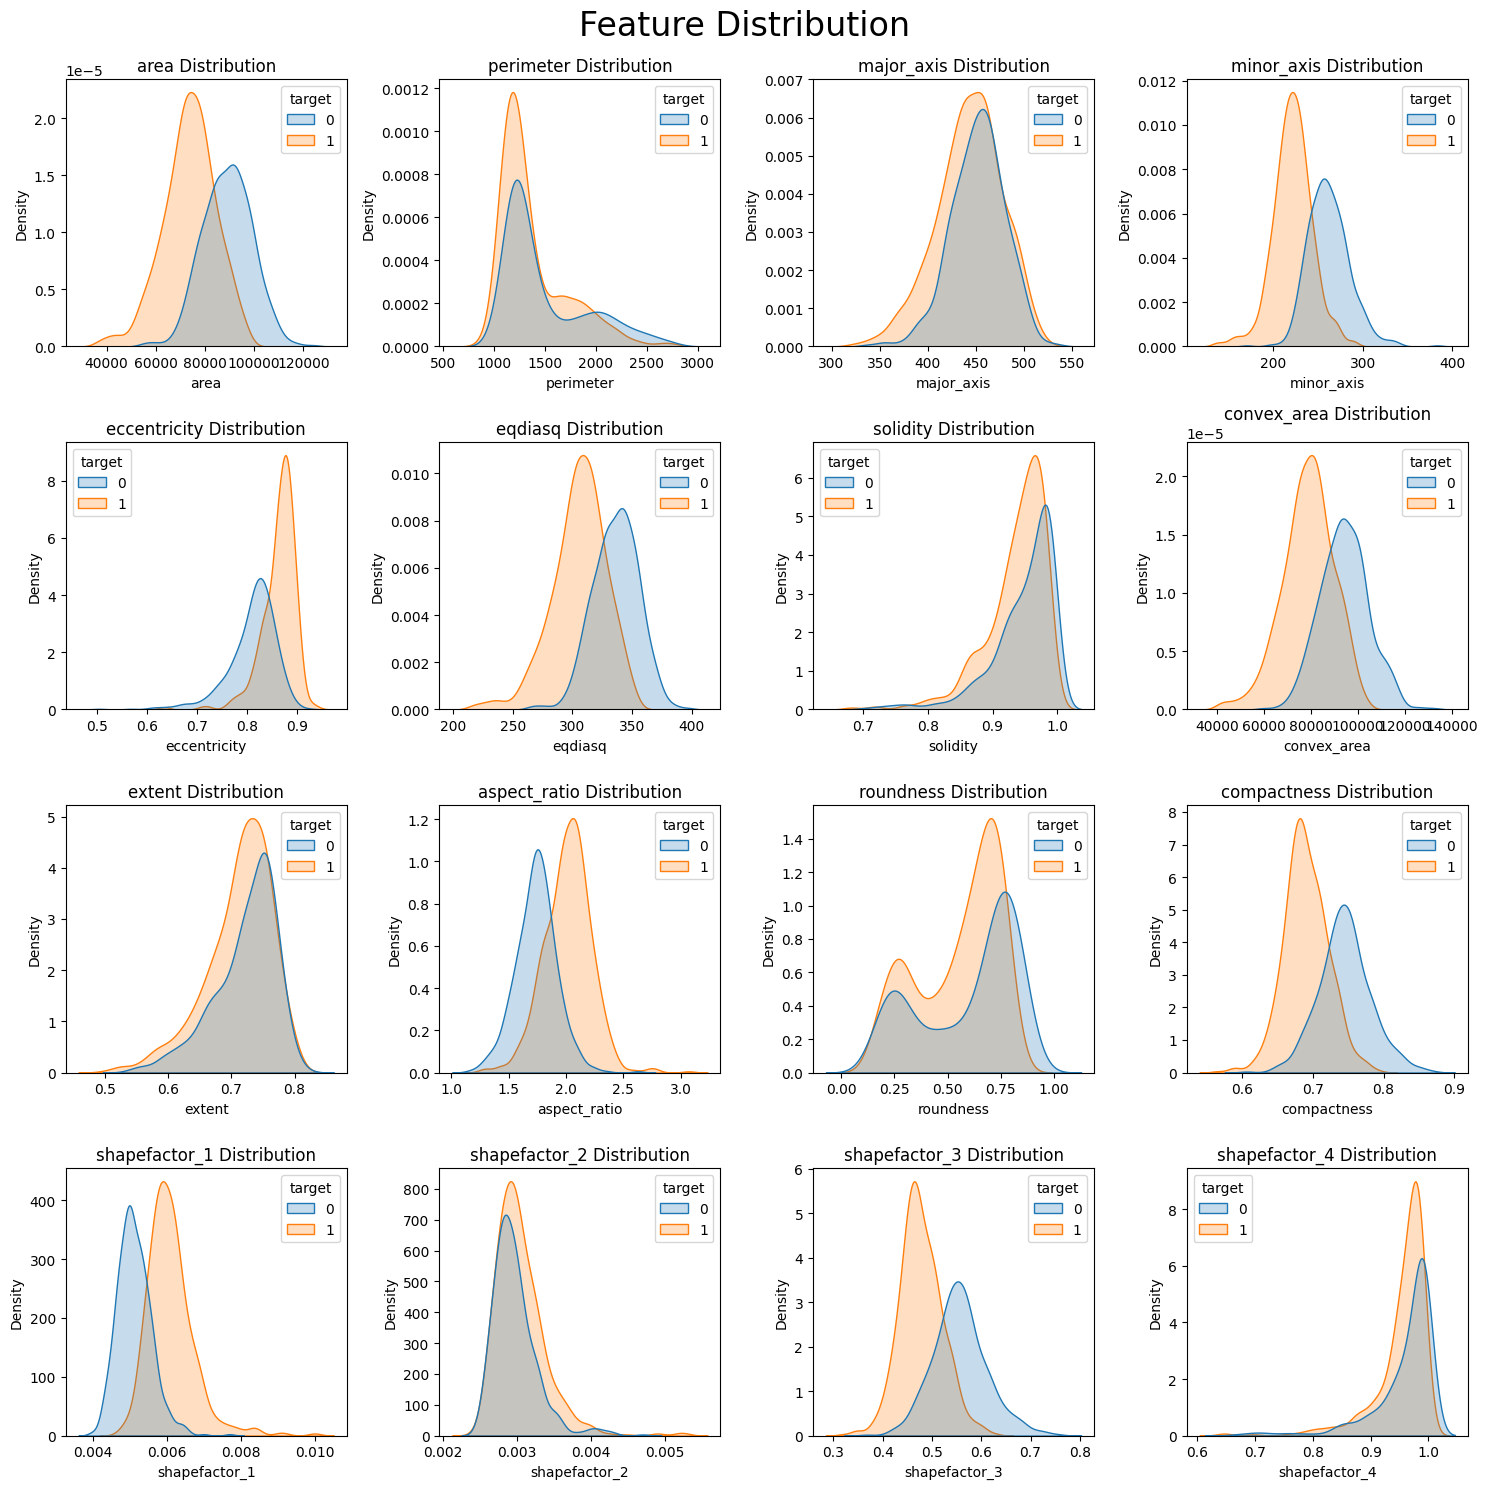

In [154]:
# Feature distribution

fig, ax = plt.subplots(4, 4, figsize=(15, 15))
idx = 0

for i in range(4):
    for j in range(4):
        column = data.drop(columns='target').columns[idx]
        sns.kdeplot(data=data, x=column, hue='target', ax=ax[i][j], fill=True)
        ax[i][j].set_title(f'{column} Distribution')
        idx += 1

fig.suptitle('Feature Distribution', fontsize=24, y=0.99)
plt.tight_layout()
plt.show()

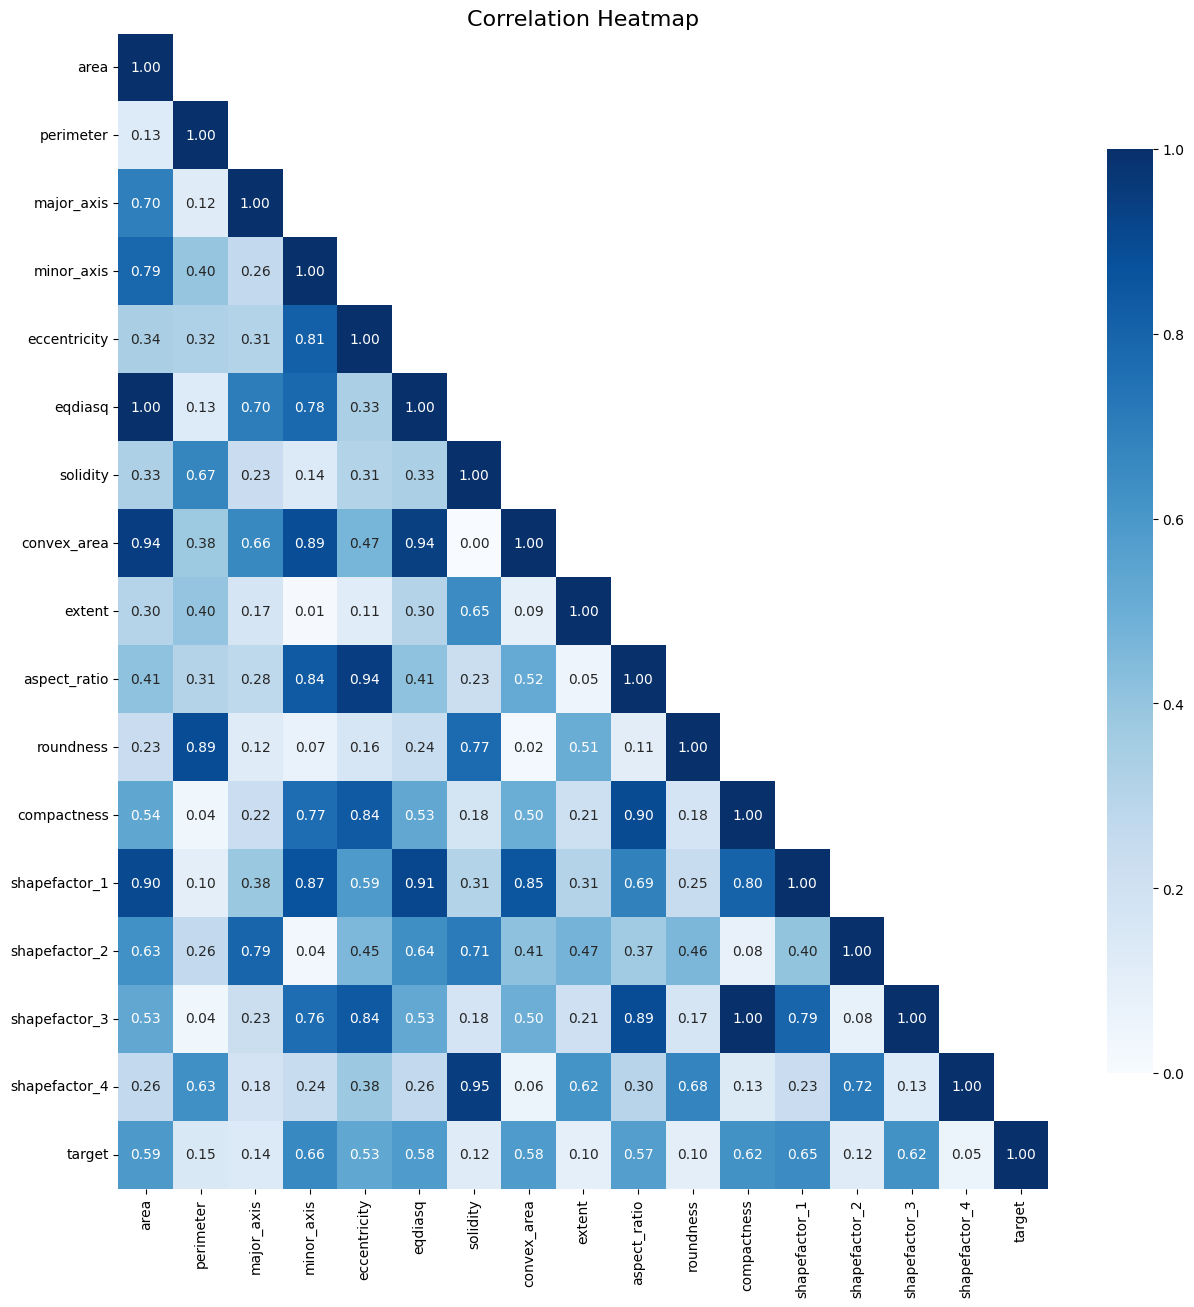

In [155]:
# Correlation heatmap

plt.figure(figsize=(15, 15))
mask = np.triu(np.ones_like(data.corr().abs(), dtype=bool), k=1)

sns.heatmap(
    data.corr().abs(),
    mask=mask,
    cmap='Blues',
    annot=True,
    fmt=".2f",
    vmin=0,
    vmax=1,
    annot_kws={"size": 10},
    cbar_kws={"shrink": 0.8}
)

plt.title('Correlation Heatmap', fontsize=16)
plt.show()

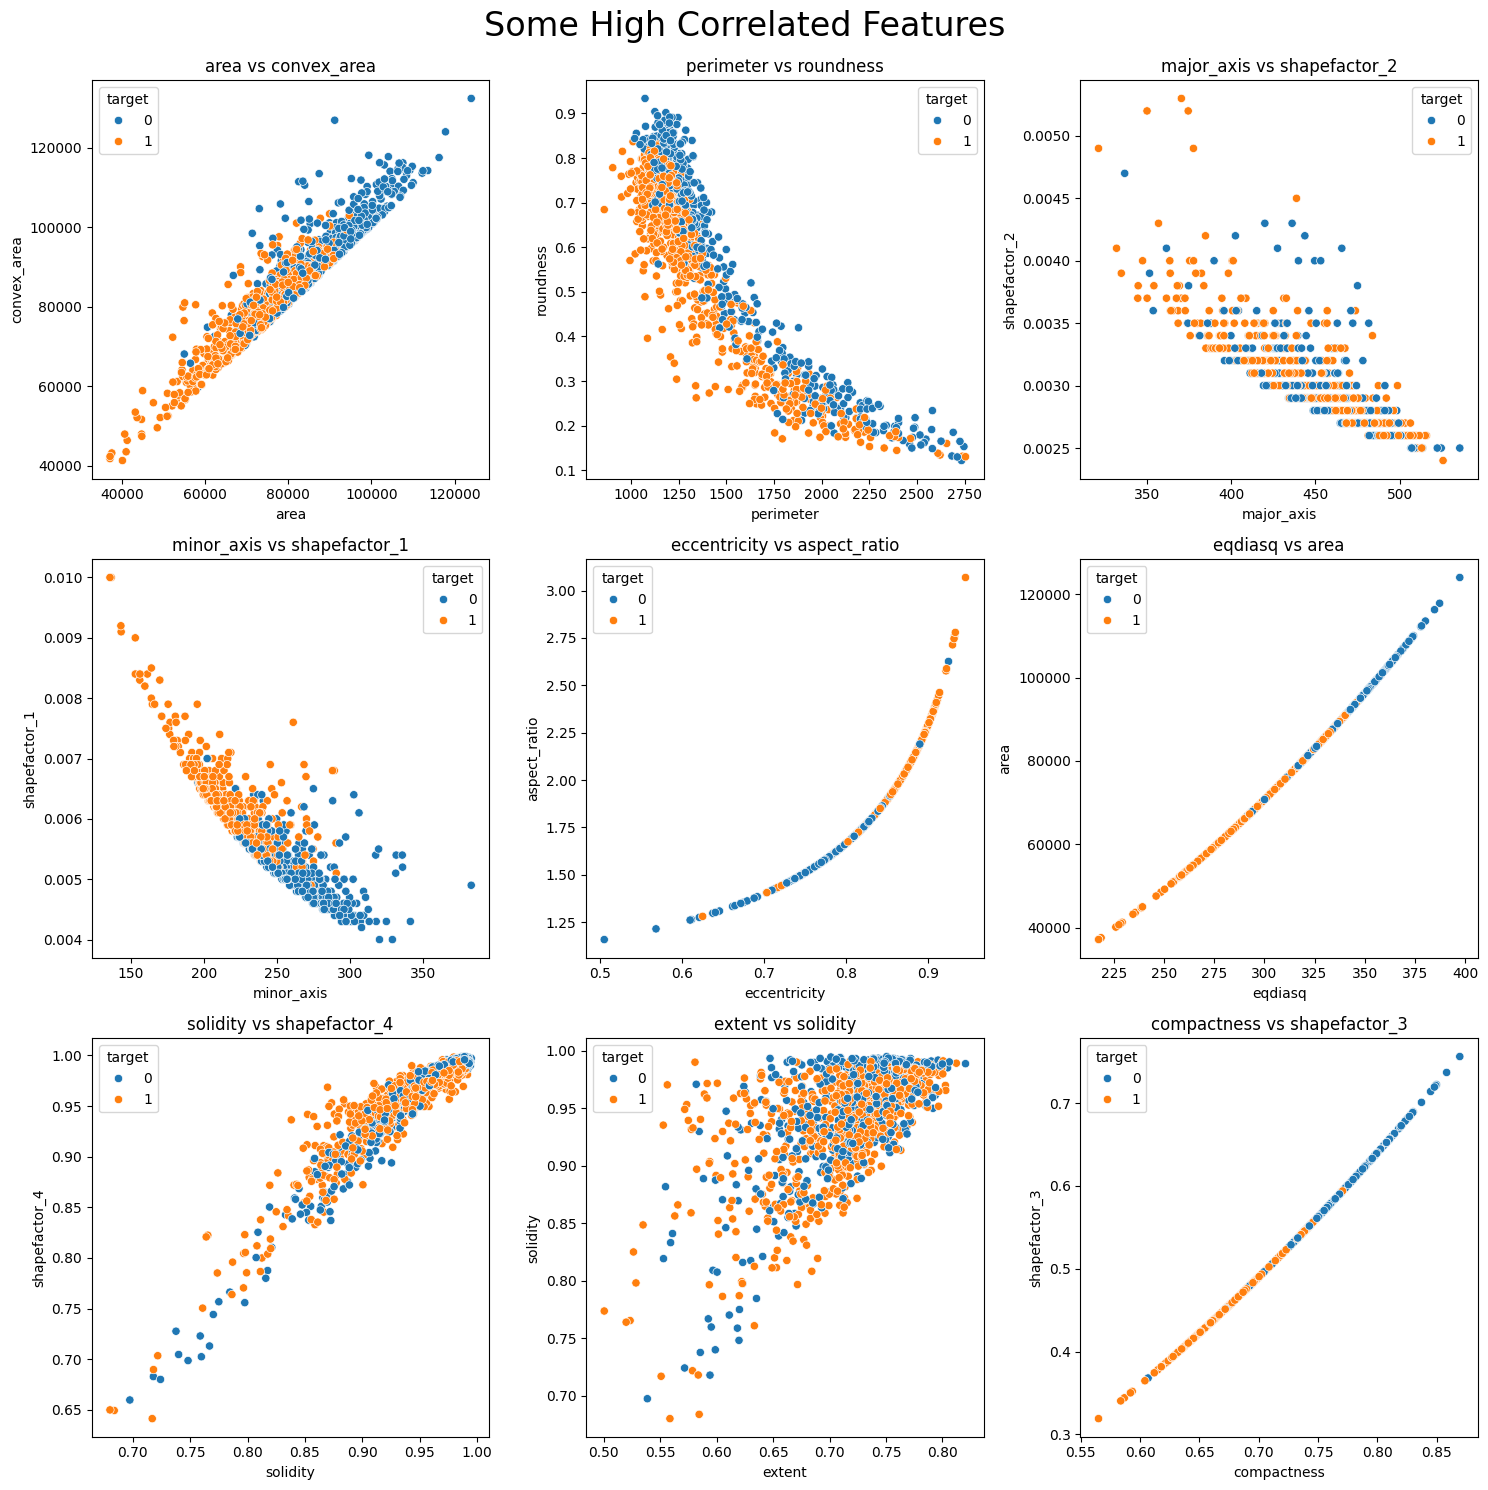

In [156]:
# Some high correlated features

fig, ax = plt.subplots(3, 3, figsize=(15, 15))

sns.scatterplot(data=data, x='area', y='convex_area', hue='target', ax=ax[0][0])
ax[0][0].set_title(f'area vs convex_area')
sns.scatterplot(data=data, x='perimeter', y='roundness', hue='target', ax=ax[0][1])
ax[0][1].set_title(f'perimeter vs roundness')
sns.scatterplot(data=data, x='major_axis', y='shapefactor_2', hue='target', ax=ax[0][2])
ax[0][2].set_title(f'major_axis vs shapefactor_2')
sns.scatterplot(data=data, x='minor_axis', y='shapefactor_1', hue='target', ax=ax[1][0])
ax[1][0].set_title(f'minor_axis vs shapefactor_1')
sns.scatterplot(data=data, x='eccentricity', y='aspect_ratio', hue='target', ax=ax[1][1])
ax[1][1].set_title(f'eccentricity vs aspect_ratio')
sns.scatterplot(data=data, x='eqdiasq', y='area', hue='target', ax=ax[1][2])
ax[1][2].set_title(f'eqdiasq vs area')
sns.scatterplot(data=data, x='solidity', y='shapefactor_4', hue='target', ax=ax[2][0])
ax[2][0].set_title(f'solidity vs shapefactor_4')
sns.scatterplot(data=data, x='extent', y='solidity', hue='target', ax=ax[2][1])
ax[2][1].set_title(f'extent vs solidity')
sns.scatterplot(data=data, x='compactness', y='shapefactor_3', hue='target', ax=ax[2][2])
ax[2][2].set_title(f'compactness vs shapefactor_3')

fig.suptitle('Some High Correlated Features', fontsize=24, y=0.99)
plt.tight_layout()
plt.show()

## EDA Summary

**Dataset Overview**

- Contains 1,288 rows (relatively small dataset)

- 16 features + 1 target variable (binary classification)


**Class distribution:**

- Class **1**: ~57%

- Class **0**: ~43%

Moderate but noticeable class imbalance


**Data Characteristics**

- All features are numeric (float/int) → No encoding required

- No missing values or duplicates detected

- Some features follow normal distribution

- Presence of highly correlated features



## Data Splitting

Due to the dataset's limited size, we'll use cross-validation rather than train-validation splitting

In [157]:
features_train = data.drop(['target'], axis=1)
target_train = data['target']

features_test = test
# target_test - none (only in Contest)

In [158]:
print(features_train.shape)
print(target_train.shape)
print()
print(features_test.shape)

(1288, 16)
(1288,)

(430, 16)


## Model Training

### LogisticRegression

In [130]:
model_LR = make_pipeline(StandardScaler(), LogisticRegression())

In [142]:
# Logistic Regression training

cross_val_lr = cross_val_score(model_LR, features_train, target_train,
                         cv = 5,
                         n_jobs = 2,
                         scoring = 'accuracy')


print(f'Accuracy LogisticRegression() обучающей выборки на кросс-валидации: {cross_val_lr}')
print(f'Mean accuracy LogisticRegression() обучающей выборки на кросс-валидации: {cross_val_lr.mean():.4%}')

Accuracy LogisticRegression() обучающей выборки на кросс-валидации: [0.86434109 0.86434109 0.87984496 0.87159533 0.85603113]
Mean accuracy LogisticRegression() обучающей выборки на кросс-валидации: 86.7231%


### CatBoostClassifier

In [134]:
grid = {
    'depth': [3, 4, 5],
    'learning_rate': [0.008, 0.009, 0.01]
}

In [135]:
# CatBoostClassifier training

model = CatBoostClassifier(iterations=1000, verbose=False)
grid_search = GridSearchCV(model, grid, cv=5, scoring='accuracy')
grid_search.fit(features_train, target_train)

GridSearchCV(cv=5,
             estimator=<catboost.core.CatBoostClassifier object at 0x7e8b64570490>,
             param_grid={'depth': [3, 4, 5],
                         'learning_rate': [0.008, 0.009, 0.01]},
             scoring='accuracy')

In [136]:
print(f"Best params: {grid_search.best_params_}")
print(f"Best CV accuracy: {grid_search.best_score_:.4f}")

Best params: {'depth': 3, 'learning_rate': 0.008}
Best CV accuracy: 0.8711


Cross-validation results indicate that CatBoostClassifier achieves higher classification accuracy than Logistic Regression on this dataset.

In [137]:
# CatBoostClassifier training on best params

final_model = CatBoostClassifier(iterations = 1000, learning_rate=0.008, depth=3, verbose=100)
final_model.fit(features_train, target_train)

0:	learn: 0.6866103	total: 1.89ms	remaining: 1.88s
100:	learn: 0.3937034	total: 141ms	remaining: 1.25s
200:	learn: 0.3273129	total: 304ms	remaining: 1.21s
300:	learn: 0.3037325	total: 442ms	remaining: 1.03s
400:	learn: 0.2906050	total: 586ms	remaining: 875ms
500:	learn: 0.2823733	total: 729ms	remaining: 726ms
600:	learn: 0.2752538	total: 872ms	remaining: 579ms
700:	learn: 0.2686407	total: 1.01s	remaining: 433ms
800:	learn: 0.2625441	total: 1.16s	remaining: 288ms
900:	learn: 0.2565238	total: 1.32s	remaining: 145ms
999:	learn: 0.2507468	total: 1.46s	remaining: 0us


In [139]:
# Predictions
test_predictions = final_model.predict(features_test)

# Saving answers
pd.DataFrame(test_predictions).to_csv('answers.csv',
                                     header=False,
                                     index=False)

Точность на тестовой выборке по данным Контеста составляет 91.4%